# Import Libraries

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Load Datasets

In [5]:
customers = pd.read_csv(
    r"C:\Users\raabh\Downloads\archive (16)\olist_customers_dataset.csv"
)

orders = pd.read_csv(
    r"C:\Users\raabh\Downloads\archive (16)\olist_orders_dataset.csv"
)

payments = pd.read_csv(
    r"C:\Users\raabh\Downloads\archive (16)\olist_order_payments_dataset.csv"
)

# Merge Tables

In [8]:
customer_df = (
    customers
    .merge(orders, on='customer_id')
    .merge(payments, on='order_id')
)

customer_df.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_sequential,payment_type,payment_installments,payment_value
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,2017-05-25 10:35:35,2017-06-05 00:00:00,1,credit_card,2,146.87
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59,2018-01-29 12:41:19,2018-02-06 00:00:00,1,credit_card,8,335.48
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-11 14:31:00,2018-06-14 17:58:51,2018-06-13 00:00:00,1,credit_card,7,157.73
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 23:22:42,2018-03-28 16:04:25,2018-04-10 00:00:00,1,credit_card,1,173.30
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-30 15:16:00,2018-08-09 20:55:48,2018-08-15 00:00:00,1,credit_card,8,252.25


# Convert Date

In [11]:
customer_df['order_purchase_timestamp'] = pd.to_datetime(
    customer_df['order_purchase_timestamp']
)

# Find Latest Date

In [14]:
reference_date = customer_df['order_purchase_timestamp'].max()

print(reference_date)

2018-10-17 17:30:18


# Create RFM Table 

In [17]:
rfm = customer_df.groupby('customer_unique_id').agg({

    'order_purchase_timestamp':
        lambda x: (reference_date - x.max()).days,

    'order_id':
        'nunique',

    'payment_value':
        'sum'

})

# Rename Columns

In [20]:
rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm.head()

,Recency,Frequency,Monetary
customer_unique_id,,,
0000366f3b9a7992bf8c76cfdf3221e2,160,1,141.90
0000b849f77a49e4a4ce2b2a4ca5be3f,163,1,27.19
0000f46a3911fa3c0805444483337064,585,1,86.22
0000f6ccb0745a6a4b88665a16c9f078,369,1,43.62
0004aac84e0df4da2b147fca70cf8255,336,1,196.89


# Exploring RFM

In [23]:
rfm.describe()

,Recency,Frequency,Monetary
count,96095.000000,96095.000000,96095.000000
mean,287.730756,1.034809,166.594226
std,153.407846,0.214385,231.428912
min,0.000000,1.000000,0.000000
25%,163.000000,1.000000,63.120000
50%,268.000000,1.000000,108.000000
75%,397.000000,1.000000,183.530000
max,772.000000,17.000000,13664.080000


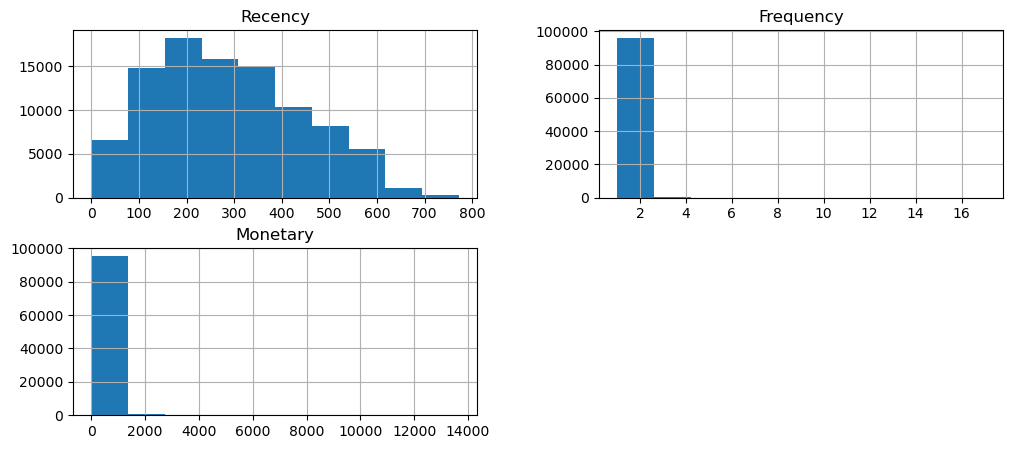

In [25]:
rfm.hist(figsize=(12,5))

plt.show()

# Scaling Features

In [28]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm)

In [30]:
rfm.head()

rfm.shape

(96095, 3)

# Entering Machine Learning Using Clusters

## Elbow Method

In [34]:
from sklearn.cluster import KMeans

inertia = []

for k in range(1, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(rfm_scaled)

    inertia.append(kmeans.inertia_)

## Plotting Elbow Curve

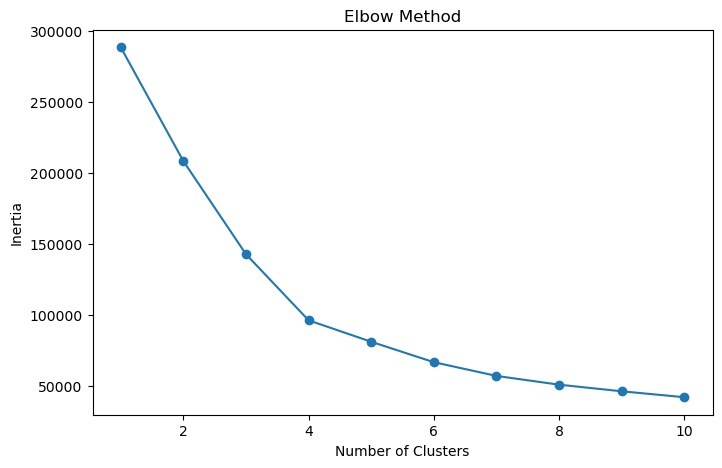

In [37]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    inertia,
    marker='o'
)

plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')

plt.show()

## Train K Means

In [40]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

## Examining Cluster Size

In [43]:
rfm['Cluster'].value_counts()

Cluster
3    52056
0    38655
2     2962
1     2422
Name: count, dtype: int64

## Cluster Summary

In [46]:
cluster_summary = rfm.groupby('Cluster').mean()

cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,437.803699,1.000000,134.926653
1,288.490091,1.015690,1196.225244
2,268.306212,2.116475,290.305945
3,177.361668,1.000000,135.164795


## Visualize Clusters

### Recency VS Monetary

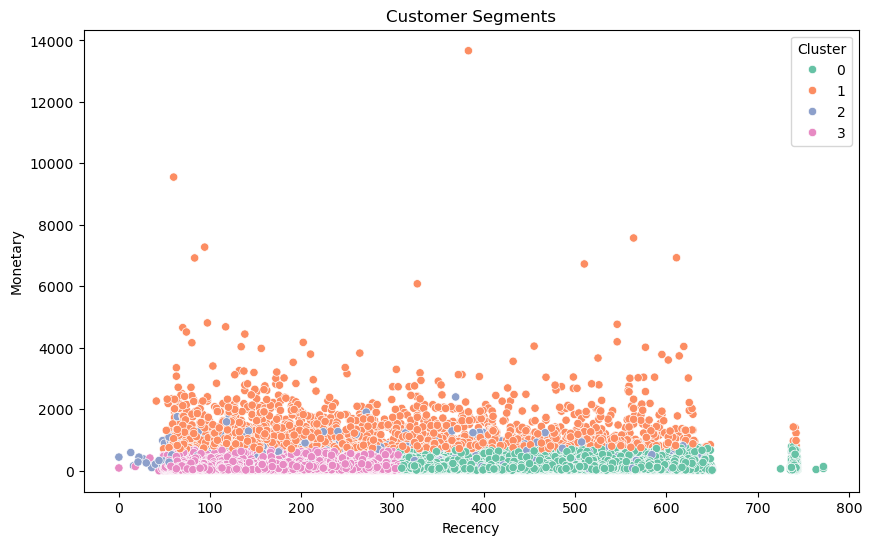

In [49]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=rfm,
    x='Recency',
    y='Monetary',
    hue='Cluster',
    palette='Set2'
)

plt.title('Customer Segments')

plt.show()

### Frequency VS Monetary

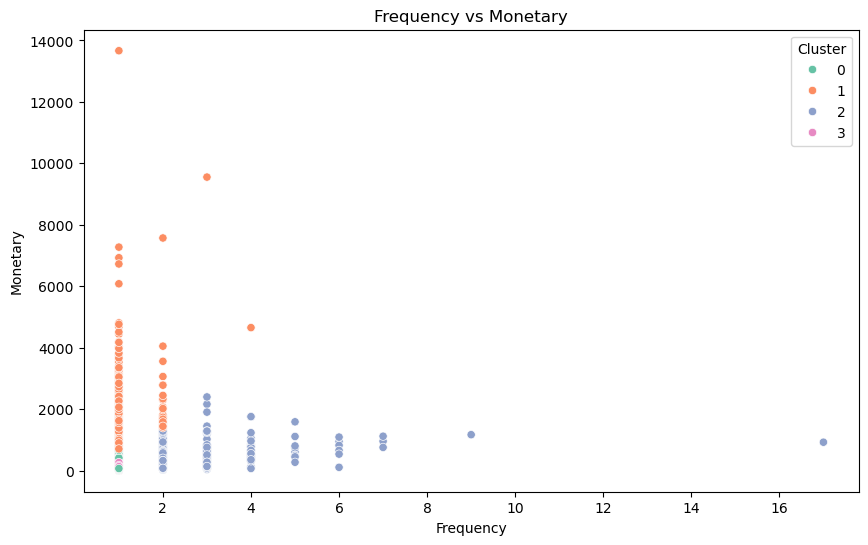

In [53]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=rfm,
    x='Frequency',
    y='Monetary',
    hue='Cluster',
    palette='Set2'
)

plt.title('Frequency vs Monetary')

plt.show()

## Naming The Clusters

In [57]:
cluster_names = {

    0: 'Loyal Customers',

    1: 'At Risk Customers',

    2: 'Regular Customers',

    3: 'VIP Customers'

}

In [59]:
rfm['Segment'] = rfm['Cluster'].map(cluster_names)

### Segment Counts

In [61]:
rfm['Segment'].value_counts()

Segment
VIP Customers        52056
Loyal Customers      38655
Regular Customers     2962
At Risk Customers     2422
Name: count, dtype: int64

### Average Metrics by Segment

In [65]:
rfm.groupby('Segment')[[
    'Recency',
    'Frequency',
    'Monetary'
]].mean()

,Recency,Frequency,Monetary
Segment,,,
At Risk Customers,288.490091,1.015690,1196.225244
Loyal Customers,437.803699,1.000000,134.926653
Regular Customers,268.306212,2.116475,290.305945
VIP Customers,177.361668,1.000000,135.164795


### Export Results

In [68]:
rfm.to_csv(
    'customer_segments.csv',
    index=False
)

# Supervised Machine Learning

## Customer Churn Prediction

## Create Recency

In [73]:
rfm.head()

,Recency,Frequency,Monetary,Cluster,Segment
customer_unique_id,,,,,
0000366f3b9a7992bf8c76cfdf3221e2,160,1,141.90,3,VIP Customers
0000b849f77a49e4a4ce2b2a4ca5be3f,163,1,27.19,3,VIP Customers
0000f46a3911fa3c0805444483337064,585,1,86.22,0,Loyal Customers
0000f6ccb0745a6a4b88665a16c9f078,369,1,43.62,0,Loyal Customers
0004aac84e0df4da2b147fca70cf8255,336,1,196.89,0,Loyal Customers


### Create Target Variable

In [76]:
rfm['Churn'] = np.where(
    rfm['Recency'] > 90,
    1,
    0
)

## Check Balance

In [79]:
rfm['Churn'].value_counts()

Churn
1    86431
0     9664
Name: count, dtype: int64

In [81]:
rfm['Churn'].value_counts(normalize=True)*100

Churn
1    89.943285
0    10.056715
Name: proportion, dtype: float64

## Define Features and Target

In [84]:
X = rfm[['Recency', 'Frequency', 'Monetary']]

y = rfm['Churn']

## Train-Test Split

In [87]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Logistic Regression

In [90]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()

lr.fit(X_train, y_train)

LogisticRegression()

## Predictions

In [93]:
y_pred = lr.predict(X_test)

## Evaluate

In [96]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("Accuracy:",
      accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1926
           1       1.00      1.00      1.00     17293

    accuracy                           1.00     19219
   macro avg       1.00      1.00      1.00     19219
weighted avg       1.00      1.00      1.00     19219



## Confusion Matrix

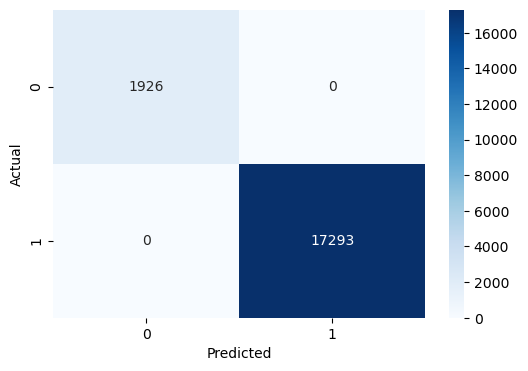

In [100]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

# Lets Use Random Forest

In [104]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

## Prediction

In [107]:
rf_pred = rf.predict(X_test)

## Evaluate

In [110]:
print(
    accuracy_score(
        y_test,
        rf_pred
    )
)

print(
    classification_report(
        y_test,
        rf_pred
    )
)

1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1926
           1       1.00      1.00      1.00     17293

    accuracy                           1.00     19219
   macro avg       1.00      1.00      1.00     19219
weighted avg       1.00      1.00      1.00     19219



## Feature Importance

In [113]:
importance = pd.DataFrame({

    'Feature': X.columns,

    'Importance': rf.feature_importances_

})

importance.sort_values(
    by='Importance',
    ascending=False
)

,Feature,Importance
0,Recency,0.999011
2,Monetary,0.000799
1,Frequency,0.000189


## Plot

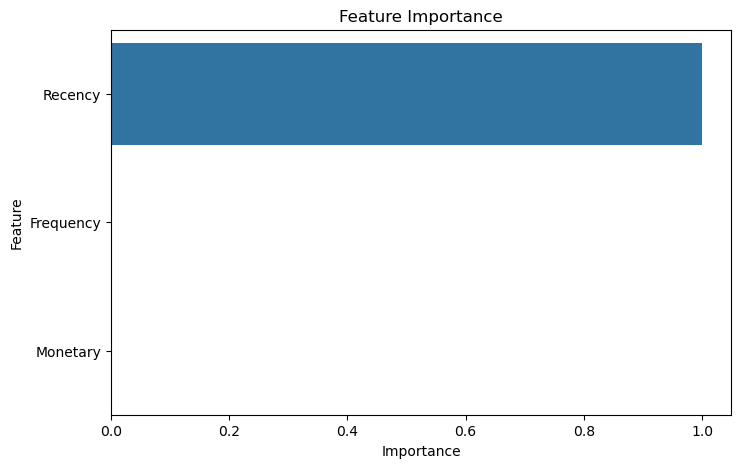

In [116]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)

plt.title('Feature Importance')

plt.show()

## ROC Curve

In [119]:
from sklearn.metrics import roc_curve, roc_auc_score

probs = rf.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(
    y_test,
    probs
)

auc = roc_auc_score(
    y_test,
    probs
)

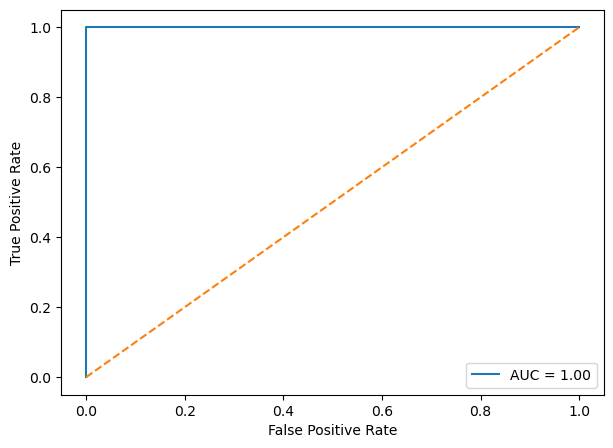

In [121]:
plt.figure(figsize=(7,5))

plt.plot(
    fpr,
    tpr,
    label=f'AUC = {auc:.2f}'
)

plt.plot(
    [0,1],
    [0,1],
    '--'
)

plt.xlabel('False Positive Rate')

plt.ylabel('True Positive Rate')

plt.legend()

plt.show()